# Week 2 Exercises

## Mathematical exercises: Pinhole camera

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import sys
sys.path.append('..')
from CV_functions import box3d, Pi, PiInv, projectpoints

### Ex 2.1

All points in bounds: False
Points out of bounds: 20
P1 projects to: [[100. 220.]]


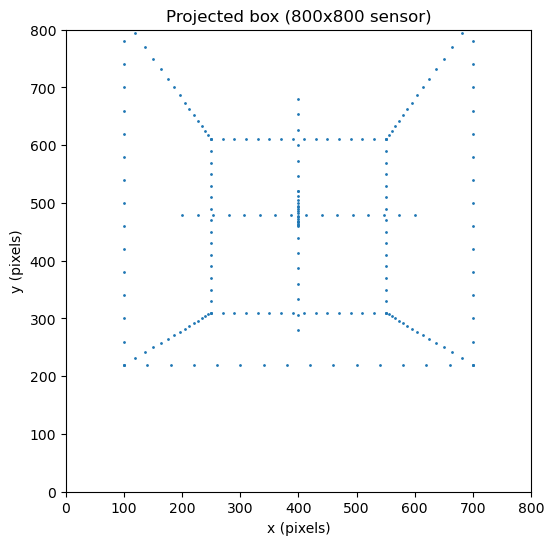

In [37]:
# Camera parameters
f = 600
delta_x = 400
delta_y = 400
K = np.array([[f, 0, delta_x],
              [0, f, delta_y],
              [0, 0,   1]])

R = np.eye(3)
t = np.array([0, 0.2, 1.5])

# Project the box
Q = box3d()
projected = projectpoints(K, R, t, Q)

# Check if all points are within the 800x800 image
in_bounds = (projected[0] >= 0) & (projected[0] <= 800) & \
            (projected[1] >= 0) & (projected[1] <= 800)
print(f"All points in bounds: {in_bounds.all()}")
print(f"Points out of bounds: {(~in_bounds).sum()}")

# Where does P1 = [-0.5, -0.5, -0.5] project to?
P1 = np.array([[-0.5], [-0.5], [-0.5]])
p1_proj = projectpoints(K, R, t, P1)
print(f"P1 projects to: {p1_proj.T}") # Should be [100, 220]

# Plot
plt.figure(figsize=(6, 6))
plt.scatter(projected[0], projected[1], s=1)
plt.xlim(0, 800)
plt.ylim(0, 800)
plt.title('Projected box (800x800 sensor)')
plt.xlabel('x (pixels)')
plt.ylabel('y (pixels)')
plt.show()

### Ex 2.2

All points in bounds: True
Points out of bounds: 0
P1 projects to: [[120.4  232.24]]


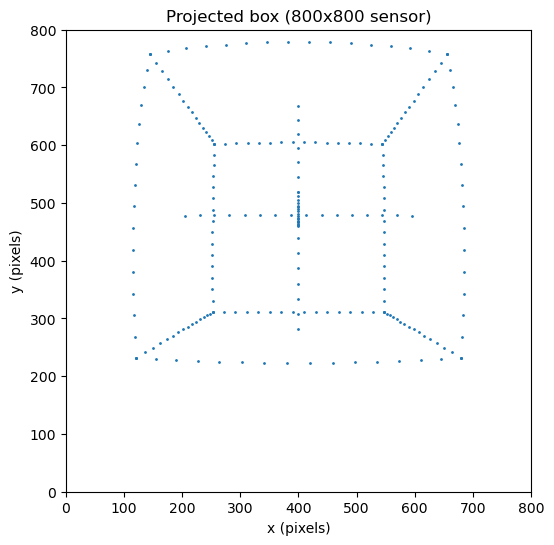

In [38]:
def projectpoints(K: np.ndarray, R: np.ndarray, t: np.ndarray, Q: np.ndarray, distCoeffs: np.ndarray) -> np.ndarray:
    '''
    Camera matrix K
    Pose of the camera (R)otation, (t)ranslation
    3xn matrix Q, which is n points in 3D to be projected
    '''
    t = t.reshape(3, 1)
    Qc = R @ Q + t
    xy = Pi(Qc)
    r = np.sqrt(xy[0]**2 + xy[1]**2)
    delta_r = sum([k * r**((i+1)*2) for i, k in enumerate(distCoeffs)])
    xy_d = xy * (1 + delta_r)
    pd = K @ PiInv(xy_d)
    return Pi(pd)

dist_coeffs = [-0.2]

# Project the box
Q = box3d()
projected = projectpoints(K, R, t, Q, dist_coeffs)

# Check if all points are within the 800x800 image
in_bounds = (projected[0] >= 0) & (projected[0] <= 800) & \
            (projected[1] >= 0) & (projected[1] <= 800)
print(f"All points in bounds: {in_bounds.all()}")
print(f"Points out of bounds: {(~in_bounds).sum()}")

# Where does P1 = [-0.5, -0.5, -0.5] project to?
P1 = np.array([[-0.5], [-0.5], [-0.5]])
p1_proj = projectpoints(K, R, t, P1, dist_coeffs)
print(f"P1 projects to: {p1_proj.T}") # Should be [100, 220]

# Plot
plt.figure(figsize=(6, 6))
plt.scatter(projected[0], projected[1], s=1)
plt.xlim(0, 800)
plt.ylim(0, 800)
plt.title('Projected box (800x800 sensor)')
plt.xlabel('x (pixels)')
plt.ylabel('y (pixels)')
plt.show()

### Ex 2.3

In [39]:
im = cv2.imread('gopro_robot.jpg')
height, width, _ = im.shape

f = 0.455732 * width

delta_x = 0.5 * width
delta_y = 0.5 * height

k3 = -0.245031
k5 = 0.071524
k7 = -0.00994978
alpha = 1
beta = 0

K = np.array([
    [f, beta*f, delta_x],
    [0, alpha*f, delta_y],
    [0, 0, 1]
])

print(K)

[[875.00544   0.      960.     ]
 [  0.      875.00544 540.     ]
 [  0.        0.        1.     ]]


### Ex 2.4

In [40]:
def undistortImage(image, K, distCoeffs):
    x, y = np.meshgrid(np.arange(image.shape[1]), np.arange(image.shape[0]))
    p = np.stack((x, y, np.ones(x.shape))).reshape(3, -1)

    q = np.linalg.inv(K) @ p
    xy = q[:2]
    r = np.sqrt(xy[0]**2 + xy[1]**2)
    delta_r = sum([k * r**((i+1)*2) for i, k in enumerate(distCoeffs)])
    xy_d = xy * (1 + delta_r)
    q_d = PiInv(xy_d)
    p_d = K @ q_d

    x_d = p_d[0].reshape(x.shape).astype(np.float32)
    y_d = p_d[1].reshape(y.shape).astype(np.float32)
    assert (p_d[2]==1).all(), 'You did a mistake somewhere'
    im_undistorted = cv2.remap(image, x_d, y_d, cv2.INTER_LINEAR)
    return im_undistorted

image = cv2.imread('gopro_robot.jpg')
undistorted_image = undistortImage(image, K, [k3, k5, k7])
cv2.imwrite('gopro_robot_undistorted.jpg', undistorted_image)

True

### Ex 2.5

In [41]:
p_2a = np.array([1, 1])
p_2b = np.array([0, 3])
p_2c = np.array([2, 3])
p_2d = np.array([2, 4])
H = np.array([
    [-2, 0, 1],
    [1, -2, 0],
    [0, 0, 3]
])
Pi(H @ PiInv(p_2a.reshape(2, 1)))
Pi(H @ PiInv(p_2b.reshape(2, 1)))
Pi(H @ PiInv(p_2c.reshape(2, 1)))
Pi(H @ PiInv(p_2d.reshape(2, 1)))

array([[-1.],
       [-2.]])

### Ex 2.6

In [42]:
def CrossOp(q):
    q = q.flatten()
    return np.cross(np.eye(3), q)

def hest(q1, q2):
    '''
    q1, q2: 2xn arrays of corresponding inhomogeneous points (q1 = H @ q2)
    '''
    n = q1.shape[1]
    Bs = []
    for i in range(n):
        q1h = PiInv(q1[:, i:i+1])   # 3x1
        q2h = PiInv(q2[:, i:i+1])   # 3x1
        Bi = np.kron(q2h.T, CrossOp(q1h))  # 3x9
        Bs.append(Bi)
    B = np.vstack(Bs)   # 3n x 9

    U, S, Vt = np.linalg.svd(B)
    v = Vt[-1, :]
    H = v.reshape(3, 3, order='F')
    return H

p_2a = np.array([1, 1])
p_2b = np.array([0, 3])
p_2c = np.array([2, 3])
p_2d = np.array([2, 4])

H = np.array([
    [-2, 0, 1],
    [1, -2, 0],
    [0, 0, 3]
])

q1a = Pi(H @ PiInv(p_2a.reshape(2, 1)))
q1b = Pi(H @ PiInv(p_2b.reshape(2, 1)))
q1c = Pi(H @ PiInv(p_2c.reshape(2, 1)))
q1d = Pi(H @ PiInv(p_2d.reshape(2, 1)))

q1 = np.hstack([q1a, q1b, q1c, q1d])   # "image 1" points, shape (2, 4)
q2 = np.hstack([p_2a.reshape(2,1), p_2b.reshape(2,1),
                p_2c.reshape(2,1), p_2d.reshape(2,1)])   # "image 2" points, shape (2, 4)

H_est = hest(q1, q2)
print("Estimated H:\n", H_est)
print("True H:\n", H)
print("Ratio (should be constant):\n", H_est / H)

Estimated H:
 [[ 4.58831468e-01  2.39391840e-16 -2.29415734e-01]
 [-2.29415734e-01  4.58831468e-01 -5.09575021e-16]
 [ 2.38958159e-16 -3.69062420e-16 -6.88247202e-01]]
True H:
 [[-2  0  1]
 [ 1 -2  0]
 [ 0  0  3]]
Ratio (should be constant):
 [[-0.22941573         inf -0.22941573]
 [-0.22941573 -0.22941573        -inf]
 [        inf        -inf -0.22941573]]


/tmp/ipykernel_3541/819891540.py:46: RuntimeWarning: divide by zero encountered in divide
  print("Ratio (should be constant):\n", H_est / H)


### Ex 2.7

In [43]:
def normalize2d(p):
    '''
    p: 2xn array of inhomogeneous 2D points
    Returns T (3x3 homogeneous transform) such that q_ih = T @ p_ih 
    has mean [0,0] and std [1,1]
    '''
    mu = p.mean(axis=1)      # [mu_x, mu_y]
    sigma = p.std(axis=1)    # [sigma_x, sigma_y]

    T_inv = np.array([
        [sigma[0], 0,          mu[0]],
        [0,          sigma[1], mu[1]],
        [0,          0,          1]
    ])
    return np.linalg.inv(T_inv) # Returns T

# some arbitrary 2D points, shape (2, n)
p = np.array([[10, 20, 15, 5],
              [50, 40, 45, 60]], dtype=float)

T = normalize2d(p)

# apply T to the points
q_h = T @ PiInv(p)
q = Pi(q_h)

print("mean:", q.mean(axis=1))   # should be ~[0, 0]
print("std:", q.std(axis=1))     # should be ~[1, 1]

mean: [-1.66533454e-16 -4.44089210e-16]
std: [1. 1.]


### Ex 2.8

In [44]:
def hest(q1, q2, normalize=True):
    '''
    q1, q2: 2xn arrays of corresponding inhomogeneous points (q1 = H @ q2)
    '''
    if normalize:
        T1 = normalize2d(q1)
        T2 = normalize2d(q2)
        q1 = Pi(T1 @ PiInv(q1))
        q2 = Pi(T2 @ PiInv(q2))

    n = q1.shape[1]
    Bs = []
    for i in range(n):
        q1h = PiInv(q1[:, i:i+1])
        q2h = PiInv(q2[:, i:i+1])
        Bi = np.kron(q2h.T, CrossOp(q1h))
        Bs.append(Bi)
    B = np.vstack(Bs)

    U, S, Vt = np.linalg.svd(B)
    v = Vt[-1, :]
    Hg = v.reshape(3, 3, order='F')

    if normalize:
        Hg = np.linalg.inv(T1) @ Hg @ T2

    return Hg

H_est_raw = hest(q1, q2, normalize=False)
H_est_norm = hest(q1, q2, normalize=True)

print("Without normalization:\n", H_est_raw / H_est_raw[-1,-1])
print("With normalization:\n", H_est_norm / H_est_norm[-1,-1])

Without normalization:
 [[-6.66666667e-01 -3.47828279e-16  3.33333333e-01]
 [ 3.33333333e-01 -6.66666667e-01  7.40395340e-16]
 [-3.47198155e-16  5.36235264e-16  1.00000000e+00]]
With normalization:
 [[-6.66666667e-01 -8.40344576e-17  3.33333333e-01]
 [ 3.33333333e-01 -6.66666667e-01  1.20981848e-15]
 [ 3.03978332e-16 -1.38775698e-16  1.00000000e+00]]


### Ex 2.9

In [45]:
# Given starting point
q2 = np.random.randn(2, 100)
q2h = np.vstack((q2, np.ones((1, 100))))
H_true = np.random.randn(3, 3)
q1h = H_true @ q2h
q1 = Pi(q1h)

# Estimate H using your hest function
H_est = hest(q1, q2, normalize=False)
H_est_norm = hest(q1, q2, normalize=True)

# Compare — normalize both matrices by their bottom-right entry to remove scale ambiguity
print("H_true (normalized):\n", H_true / H_true[-1, -1])
print("H_est (normalized):\n", H_est / H_est[-1, -1])
print("H_est_norm (normalized):\n", H_est_norm / H_est_norm[-1, -1])

H_true (normalized):
 [[-14.81462526  32.53008116  47.34095179]
 [-57.54386221 -37.23839749 -14.20006555]
 [  7.8808587   15.12069218   1.        ]]
H_est (normalized):
 [[-14.81462526  32.53008116  47.34095179]
 [-57.54386221 -37.23839749 -14.20006555]
 [  7.8808587   15.12069218   1.        ]]
H_est_norm (normalized):
 [[-14.81462526  32.53008116  47.34095179]
 [-57.54386221 -37.23839749 -14.20006555]
 [  7.8808587   15.12069218   1.        ]]


In [46]:
q1_est = Pi(H_est @ q2h)
error = np.linalg.norm(q1 - q1_est, axis=0)
print("Max reprojection error (no normalization):", error.max())

q1_est_norm = Pi(H_est_norm @ q2h)
error_norm = np.linalg.norm(q1 - q1_est_norm, axis=0)
print("Max reprojection error (with normalization):", error_norm.max())

Max reprojection error (no normalization): 4.270297970623978e-10
Max reprojection error (with normalization): 1.8984980280718285e-10
